In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/bhanupratapbiswas/website-traffic-analysis/traffic.csv")

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [2]:
print("Shape:", df.shape)

df.info()

Shape: (226278, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [3]:
df.describe()

,event,date,country,city,artist,album,track,isrc,linkid
count,226278,226278,226267,226267,226241,226273,226273,219157,226278
unique,3,7,211,11993,2419,3254,3562,709,3839
top,pageview,2021-08-19,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
freq,142015,35361,47334,22791,40841,40841,40841,40841,40841


In [4]:
df.isnull().sum()

event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64

In [5]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

print("New Shape:", df.shape)

Duplicates: 103711
New Shape: (122567, 9)


In [6]:
df.columns

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')

In [8]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
5,click,2021-08-21,United States,Los Angeles,KenTheMan,I'm Perfect,I'm Perfect,US39N2102090,190c7170-4044-4c97-9709-926917155b02


In [9]:
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Month_Name'] = df['date'].dt.month_name()
df['Day'] = df['date'].dt.day_name()

In [10]:
total_events = len(df)
total_countries = df['country'].nunique()
total_cities = df['city'].nunique()
total_artists = df['artist'].nunique()
total_albums = df['album'].nunique()
total_tracks = df['track'].nunique()

print("Total Events:", total_events)
print("Total Countries:", total_countries)
print("Total Cities:", total_cities)
print("Total Artists:", total_artists)
print("Total Albums:", total_albums)
print("Total Tracks:", total_tracks)

Total Events: 122567
Total Countries: 211
Total Cities: 11993
Total Artists: 2419
Total Albums: 3254
Total Tracks: 3562


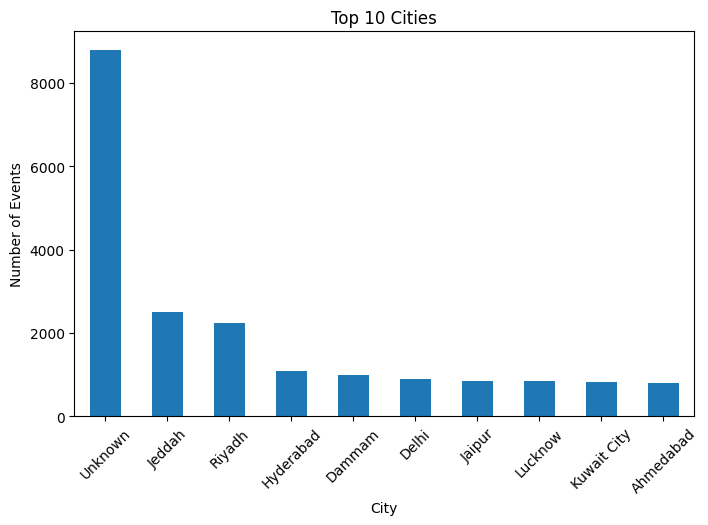

In [12]:
top_cities = df['city'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_cities.plot(kind='bar')

plt.title('Top 10 Cities')
plt.xlabel('City')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)

plt.show()

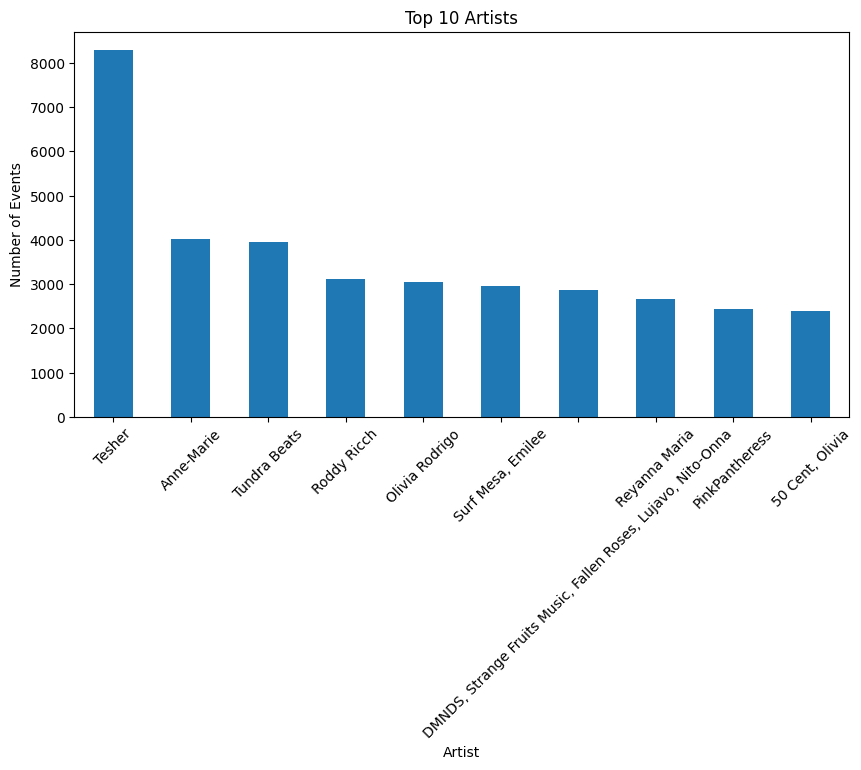

In [13]:
top_artists = df['artist'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_artists.plot(kind='bar')

plt.title('Top 10 Artists')
plt.xlabel('Artist')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)

plt.show()

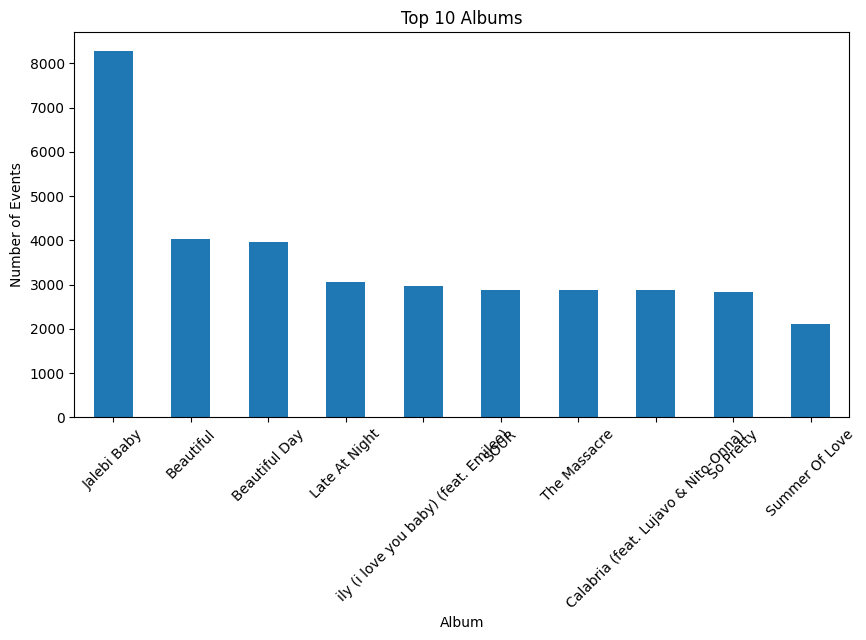

In [14]:
top_albums = df['album'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_albums.plot(kind='bar')

plt.title('Top 10 Albums')
plt.xlabel('Album')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)

plt.show()

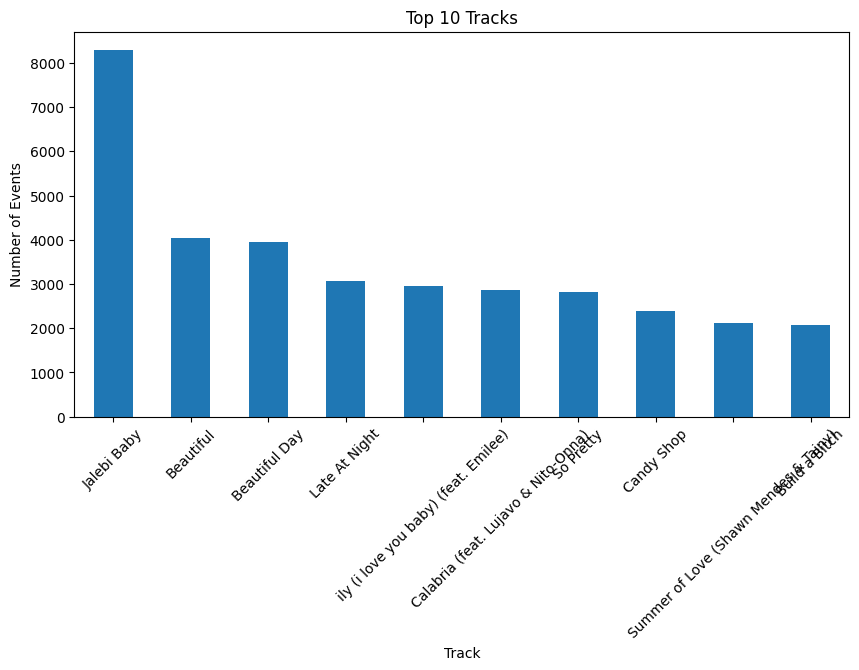

In [15]:
top_tracks = df['track'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_tracks.plot(kind='bar')

plt.title('Top 10 Tracks')
plt.xlabel('Track')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)

plt.show()

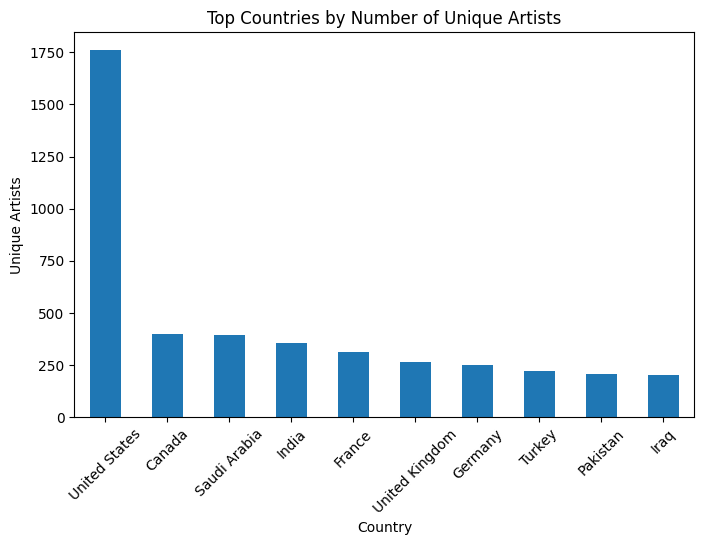

In [16]:
country_artists = df.groupby('country')['artist'].nunique().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(8,5))
country_artists.plot(kind='bar')

plt.title('Top Countries by Number of Unique Artists')
plt.xlabel('Country')
plt.ylabel('Unique Artists')
plt.xticks(rotation=45)

plt.show()

In [17]:
artist_summary = df.groupby('artist').agg(
    Events=('artist', 'count'),
    Unique_Tracks=('track', 'nunique'),
    Unique_Albums=('album', 'nunique'),
    Countries=('country', 'nunique')
).sort_values('Events', ascending=False)

artist_summary.head(10)

,Events,Unique_Tracks,Unique_Albums,Countries
artist,,,,
Tesher,8288,1,1,160
Anne-Marie,4029,2,2,140
Tundra Beats,3951,2,2,139
Roddy Ricch,3107,5,3,126
Olivia Rodrigo,3037,9,4,90
"Surf Mesa, Emilee",2956,1,1,94
"DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna",2865,1,1,111
Reyanna Maria,2675,1,1,124
PinkPantheress,2446,6,6,97


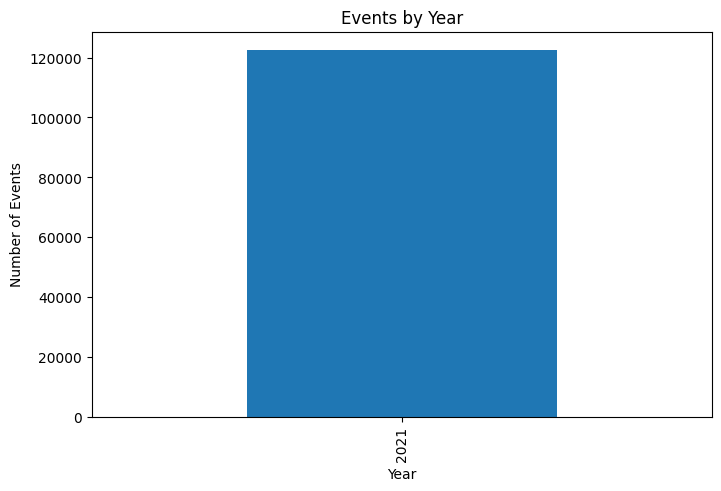

In [18]:
yearly_events = df.groupby('Year').size()

plt.figure(figsize=(8,5))
yearly_events.plot(kind='bar')

plt.title('Events by Year')
plt.xlabel('Year')
plt.ylabel('Number of Events')

plt.show()

In [19]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

isrc       6306
artist       28
city          5
country       5
album         4
track         4
dtype: int64

In [20]:
print("===== FINAL SUMMARY =====")
print("Total Events:", len(df))
print("Countries:", df['country'].nunique())
print("Cities:", df['city'].nunique())
print("Artists:", df['artist'].nunique())
print("Albums:", df['album'].nunique())
print("Tracks:", df['track'].nunique())

print("\nTop Artist:")
print(df['artist'].value_counts().idxmax())

print("\nTop Country:")
print(df['country'].value_counts().idxmax())

print("\nTop Track:")
print(df['track'].value_counts().idxmax())

===== FINAL SUMMARY =====
Total Events: 122567
Countries: 211
Cities: 11993
Artists: 2419
Albums: 3254
Tracks: 3562

Top Artist:
Tesher

Top Country:
United States

Top Track:
Jalebi Baby
